In [ ]:
from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path

DATASET_ROOT = Path("/content/drive/MyDrive/sen1floods11")

s1_dir = DATASET_ROOT / "S1Hand"
s2_dir = DATASET_ROOT / "S2Hand"
label_dir = DATASET_ROOT / "LabelHand"

for folder in [s1_dir, s2_dir, label_dir]:
    if not folder.exists():
        raise FileNotFoundError(f"Dataset folder not found: {folder}")

print("Dataset root:", DATASET_ROOT)
print("S1 files:", len(list(s1_dir.glob("*_S1Hand.tif"))))
print("S2 files:", len(list(s2_dir.glob("*_S2Hand.tif"))))
print("Label files:", len(list(label_dir.glob("*_LabelHand.tif"))))

Mounted at /content/drive
Dataset root: /content/drive/MyDrive/sen1floods11
S1 files: 446
S2 files: 446
Label files: 446


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Torch:", torch.__version__, "| Device:", device)

!pip install transformers -q
!pip install timm -q

from transformers import SegformerModel, SegformerConfig
print("Transformers ready")

Torch: 2.11.0+cu128 | Device: cuda
Transformers ready


In [ ]:
class CrossModalAttention(nn.Module):
    """
    S2 and S1 attend to each other.
    Uses sequence reduction (sr_ratio) to keep attention affordable
    at high-resolution feature levels.
    """
    def __init__(self, dim, num_heads, sr_ratio=1):
        super().__init__()
        assert dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5
        self.sr_ratio = sr_ratio

        self.q_proj  = nn.Linear(dim, dim)
        self.kv_proj = nn.Linear(dim, dim * 2)
        self.out_proj = nn.Linear(dim, dim)
        self.norm_q  = nn.LayerNorm(dim)
        self.norm_kv = nn.LayerNorm(dim)

        if sr_ratio > 1:
            self.sr      = nn.Conv2d(dim, dim, kernel_size=sr_ratio, stride=sr_ratio)
            self.sr_norm = nn.LayerNorm(dim)

    def forward(self, query_feat, kv_feat):
        """
        query_feat: (B, C, H, W)  — modality being enhanced
        kv_feat:    (B, C, H, W)  — modality providing context
        """
        B, C, H, W = query_feat.shape

        q_seq = query_feat.flatten(2).transpose(1, 2)
        q_seq = self.norm_q(q_seq)

        if self.sr_ratio > 1:
            kv_reduced = self.sr(kv_feat)
            kv_seq = kv_reduced.flatten(2).transpose(1, 2)
            kv_seq = self.sr_norm(kv_seq)
        else:
            kv_seq = kv_feat.flatten(2).transpose(1, 2)
            kv_seq = self.norm_kv(kv_seq)

        Q  = self.q_proj(q_seq)
        KV = self.kv_proj(kv_seq)
        K, V = KV.chunk(2, dim=-1)

        def to_heads(t, n):
            return t.reshape(B, n, self.num_heads, self.head_dim).transpose(1, 2)

        Q = to_heads(Q, H * W)
        K = to_heads(K, kv_seq.shape[1])
        V = to_heads(V, kv_seq.shape[1])

        attn = (Q @ K.transpose(-2, -1)) * self.scale
        attn = attn.softmax(dim=-1)

        out = (attn @ V).transpose(1, 2).reshape(B, H * W, C)
        out = self.out_proj(out)


        out = (q_seq + out).transpose(1, 2).reshape(B, C, H, W)
        return out

In [ ]:
class MLPDecoder(nn.Module):
    """
    Takes 4 fused feature maps at different scales,
    projects each to decoder_dim, upsamples all to H/4,
    concatenates and produces final prediction.
    """
    def __init__(self, embed_dims, decoder_dim=256, num_classes=1):
        super().__init__()
        self.linear_layers = nn.ModuleList([
            nn.Linear(dim, decoder_dim) for dim in embed_dims
        ])
        self.fuse = nn.Sequential(
            nn.Conv2d(decoder_dim * len(embed_dims), decoder_dim, 1, bias=False),
            nn.BatchNorm2d(decoder_dim),
            nn.ReLU(inplace=True),
            nn.Dropout2d(0.1),
        )
        self.head = nn.Conv2d(decoder_dim, num_classes, 1)

    def forward(self, features):
        B, _, H4, W4 = features[0].shape

        outs = []
        for feat, mlp in zip(features, self.linear_layers):
            B, C, H, W = feat.shape
            feat = feat.flatten(2).transpose(1, 2)
            feat = mlp(feat)
            feat = feat.transpose(1, 2).reshape(B, -1, H, W)
            feat = F.interpolate(feat, size=(H4, W4), mode='bilinear', align_corners=False)
            outs.append(feat)

        out = self.fuse(torch.cat(outs, dim=1))
        out = self.head(out)
        out = F.interpolate(out, scale_factor=4, mode='bilinear', align_corners=False)
        return out

In [ ]:
from transformers import SegformerModel, SegformerConfig

class DualSegFormer(nn.Module):
    EMBED_DIMS = [32, 64, 160, 256]
    SR_RATIOS = [8, 4, 2, 1]
    NUM_HEADS = [1, 2, 5, 8]

    def __init__(self, s2_in_ch=8, s1_in_ch=3, num_classes=1,
                 pretrained=True, fusion="bidirectional_multiscale"):
        super().__init__()
        self.s2_encoder = self._build_encoder(s2_in_ch, pretrained)
        self.s1_encoder = self._build_encoder(s1_in_ch, pretrained)
        self.fusion = fusion

        if fusion == "bidirectional_multiscale":
            self.attn_s2 = nn.ModuleList([
                CrossModalAttention(dim, heads, sr)
                for dim, heads, sr in zip(self.EMBED_DIMS, self.NUM_HEADS, self.SR_RATIOS)
            ])
            self.attn_s1 = nn.ModuleList([
                CrossModalAttention(dim, heads, sr)
                for dim, heads, sr in zip(self.EMBED_DIMS, self.NUM_HEADS, self.SR_RATIOS)
            ])
        elif fusion == "unidirectional_multiscale":
            self.attn_s2 = nn.ModuleList([
                CrossModalAttention(dim, heads, sr)
                for dim, heads, sr in zip(self.EMBED_DIMS, self.NUM_HEADS, self.SR_RATIOS)
            ])
        elif fusion == "single_scale":
            self.attn_s2 = CrossModalAttention(self.EMBED_DIMS[-1], self.NUM_HEADS[-1], self.SR_RATIOS[-1])
            self.attn_s1 = CrossModalAttention(self.EMBED_DIMS[-1], self.NUM_HEADS[-1], self.SR_RATIOS[-1])
        elif fusion != "late_average":
            raise ValueError(f"Unknown fusion method: {fusion}")

        self.decoder = MLPDecoder(self.EMBED_DIMS, decoder_dim=256, num_classes=num_classes)

    def _build_encoder(self, in_channels, pretrained):
        if pretrained:
            encoder = SegformerModel.from_pretrained("nvidia/mit-b0")
        else:
            encoder = SegformerModel(SegformerConfig(
                num_channels=3,
                hidden_sizes=self.EMBED_DIMS,
                depths=[2, 2, 2, 2],
                num_attention_heads=self.NUM_HEADS,
                sr_ratios=self.SR_RATIOS,
            ))
        if in_channels != 3:
            self._adapt_first_layer(encoder, in_channels, pretrained)
        return encoder

    def _adapt_first_layer(self, encoder, in_channels, pretrained):
        old = encoder.stages[0].patch_embeddings.proj
        new = nn.Conv2d(in_channels, old.out_channels, kernel_size=old.kernel_size,
                        stride=old.stride, padding=old.padding,
                        bias=(old.bias is not None))
        if pretrained:
            with torch.no_grad():
                average_weight = old.weight.data.mean(dim=1, keepdim=True)
                new.weight.copy_(average_weight.repeat(1, in_channels, 1, 1))
                if old.bias is not None:
                    new.bias.copy_(old.bias)
        encoder.stages[0].patch_embeddings.proj = new

    def _extract_features(self, encoder, x):
        batch_size, _, height, width = x.shape
        output = encoder(x, output_hidden_states=True)
        sizes = [(height // 4, width // 4), (height // 8, width // 8),
                 (height // 16, width // 16), (height // 32, width // 32)]
        features = []
        for hidden_state, (h, w) in zip(output.hidden_states, sizes):
            if hidden_state.dim() == 3:
                hidden_state = hidden_state.reshape(batch_size, h, w, -1).permute(0, 3, 1, 2).contiguous()
            features.append(hidden_state)
        return features

    def forward(self, s2, s1):
        s2_features = self._extract_features(self.s2_encoder, s2)
        s1_features = self._extract_features(self.s1_encoder, s1)

        if self.fusion == "late_average":
            fused = [(s2_f + s1_f) / 2 for s2_f, s1_f in zip(s2_features, s1_features)]
        elif self.fusion == "unidirectional_multiscale":
            fused = [attention(s2_f, s1_f) for s2_f, s1_f, attention in zip(s2_features, s1_features, self.attn_s2)]
        elif self.fusion == "single_scale":
            fused = []
            for index, (s2_f, s1_f) in enumerate(zip(s2_features, s1_features)):
                if index == len(s2_features) - 1:
                    fused.append(self.attn_s2(s2_f, s1_f) + self.attn_s1(s1_f, s2_f))
                else:
                    fused.append((s2_f + s1_f) / 2)
        else:
            fused = [a2(s2_f, s1_f) + a1(s1_f, s2_f)
                     for s2_f, s1_f, a2, a1 in zip(s2_features, s1_features, self.attn_s2, self.attn_s1)]
        return self.decoder(fused)

In [ ]:
class EarlyConcatSegFormer(nn.Module):
    """Ablation: concatenate S1 and S2 at input, then use one encoder."""
    EMBED_DIMS = [32, 64, 160, 256]

    def __init__(self, s2_in_ch=8, s1_in_ch=3, num_classes=1, pretrained=True):
        super().__init__()
        total_channels = s2_in_ch + s1_in_ch
        if pretrained:
            self.encoder = SegformerModel.from_pretrained("nvidia/mit-b0")
        else:
            self.encoder = SegformerModel(SegformerConfig(
                num_channels=3, hidden_sizes=self.EMBED_DIMS, depths=[2, 2, 2, 2],
                num_attention_heads=[1, 2, 5, 8], sr_ratios=[8, 4, 2, 1],
            ))
        old = self.encoder.stages[0].patch_embeddings.proj
        new = nn.Conv2d(total_channels, old.out_channels, kernel_size=old.kernel_size,
                        stride=old.stride, padding=old.padding, bias=(old.bias is not None))
        if pretrained:
            with torch.no_grad():
                new.weight.copy_(old.weight.mean(dim=1, keepdim=True).repeat(1, total_channels, 1, 1))
                if old.bias is not None:
                    new.bias.copy_(old.bias)
        self.encoder.stages[0].patch_embeddings.proj = new
        self.decoder = MLPDecoder(self.EMBED_DIMS, decoder_dim=256, num_classes=num_classes)

    def forward(self, s2, s1):
        x = torch.cat([s2, s1], dim=1)
        batch_size, _, height, width = x.shape
        output = self.encoder(x, output_hidden_states=True)
        sizes = [(height // 4, width // 4), (height // 8, width // 8),
                 (height // 16, width // 16), (height // 32, width // 32)]
        features = []
        for hidden_state, (h, w) in zip(output.hidden_states, sizes):
            if hidden_state.dim() == 3:
                hidden_state = hidden_state.reshape(batch_size, h, w, -1).permute(0, 3, 1, 2).contiguous()
            features.append(hidden_state)
        return self.decoder(features)


class SingleModalitySegFormer(nn.Module):
    """Use in_channels=3 for S1-only and in_channels=8 for S2-only."""
    EMBED_DIMS = [32, 64, 160, 256]

    def __init__(self, in_channels, num_classes=1, pretrained=True):
        super().__init__()
        if pretrained:
            self.encoder = SegformerModel.from_pretrained("nvidia/mit-b0")
        else:
            self.encoder = SegformerModel(SegformerConfig(
                num_channels=3, hidden_sizes=self.EMBED_DIMS, depths=[2, 2, 2, 2],
                num_attention_heads=[1, 2, 5, 8], sr_ratios=[8, 4, 2, 1],
            ))
        if in_channels != 3:
            old = self.encoder.stages[0].patch_embeddings.proj
            new = nn.Conv2d(in_channels, old.out_channels, kernel_size=old.kernel_size,
                            stride=old.stride, padding=old.padding, bias=(old.bias is not None))
            if pretrained:
                with torch.no_grad():
                    new.weight.copy_(old.weight.mean(dim=1, keepdim=True).repeat(1, in_channels, 1, 1))
                    if old.bias is not None:
                        new.bias.copy_(old.bias)
            self.encoder.stages[0].patch_embeddings.proj = new
        self.decoder = MLPDecoder(self.EMBED_DIMS, decoder_dim=256, num_classes=num_classes)

    def forward(self, x):
        batch_size, _, height, width = x.shape
        output = self.encoder(x, output_hidden_states=True)
        sizes = [(height // 4, width // 4), (height // 8, width // 8),
                 (height // 16, width // 16), (height // 32, width // 32)]
        features = []
        for hidden_state, (h, w) in zip(output.hidden_states, sizes):
            if hidden_state.dim() == 3:
                hidden_state = hidden_state.reshape(batch_size, h, w, -1).permute(0, 3, 1, 2).contiguous()
            features.append(hidden_state)
        return self.decoder(features)


class S1OnlyWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, s2, s1):
        return self.model(s1)


class S2OnlyWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

In [ ]:
class S2OnlyWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, s2, s1):
        return self.model(s2)


EXPERIMENTS = [
    "full_bidirectional_pretrained",
    "late_average",
    "unidirectional",
    "single_scale",
    "early_concat",
    "s1_only",
    "s2_only",
    "full_bidirectional_random_init",
]


def build_model(experiment_name):
    if experiment_name == "full_bidirectional_pretrained":
        return DualSegFormer(
            pretrained=True,
            fusion="bidirectional_multiscale",
        ).to(device)

    if experiment_name == "late_average":
        return DualSegFormer(
            pretrained=True,
            fusion="late_average",
        ).to(device)

    if experiment_name == "unidirectional":
        return DualSegFormer(
            pretrained=True,
            fusion="unidirectional_multiscale",
        ).to(device)

    if experiment_name == "single_scale":
        return DualSegFormer(
            pretrained=True,
            fusion="single_scale",
        ).to(device)

    if experiment_name == "early_concat":
        return EarlyConcatSegFormer(pretrained=True).to(device)

    if experiment_name == "s1_only":
        return S1OnlyWrapper(
            SingleModalitySegFormer(in_channels=3, pretrained=True)
        ).to(device)

    if experiment_name == "s2_only":
        return S2OnlyWrapper(
            SingleModalitySegFormer(in_channels=8, pretrained=True)
        ).to(device)

    if experiment_name == "full_bidirectional_random_init":
        return DualSegFormer(
            pretrained=False,
            fusion="bidirectional_multiscale",
        ).to(device)

    raise ValueError(f"Unknown experiment: {experiment_name}")


s2_dummy = torch.randn(2, 8, 512, 512, device=device)
s1_dummy = torch.randn(2, 3, 512, 512, device=device)

for experiment_name in EXPERIMENTS:
    model = build_model(experiment_name)

    with torch.no_grad():
        output = model(s2_dummy, s1_dummy)

    print(f"{experiment_name:35s} -> {tuple(output.shape)}")
    assert output.shape == (2, 1, 512, 512)

    del model
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("All architectures passed the output-shape test.")

config.json:   0%|          | 0.00/70.0k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B / 14.4MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

[transformers] SegformerModel LOAD REPORT from: nvidia/mit-b0
Key               | Status     |  | 
------------------+------------+--+-
classifier.weight | UNEXPECTED |  | 
classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

[transformers] SegformerModel LOAD REPORT from: nvidia/mit-b0
Key               | Status     |  | 
------------------+------------+--+-
classifier.weight | UNEXPECTED |  | 
classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


s1_only                             -> (2, 1, 512, 512)


Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

[transformers] SegformerModel LOAD REPORT from: nvidia/mit-b0
Key               | Status     |  | 
------------------+------------+--+-
classifier.weight | UNEXPECTED |  | 
classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


s2_only                             -> (2, 1, 512, 512)
full_bidirectional_random_init      -> (2, 1, 512, 512)
All architectures passed the output-shape test.


In [ ]:
import os

OUTPUT_ROOT = "/content/drive/MyDrive/S1S2_Fusion Architecture_output"

CHECKPOINT_DIR = os.path.join(OUTPUT_ROOT, "checkpoints")
RESULTS_DIR = os.path.join(OUTPUT_ROOT, "results")
FIGURES_DIR = os.path.join(OUTPUT_ROOT, "figures")
INFERENCE_DIR = os.path.join(OUTPUT_ROOT, "inference")
GRADCAM_DIR = os.path.join(OUTPUT_ROOT, "gradcam")

for folder in [
    OUTPUT_ROOT,
    CHECKPOINT_DIR,
    RESULTS_DIR,
    FIGURES_DIR,
    INFERENCE_DIR,
    GRADCAM_DIR,
]:
    os.makedirs(folder, exist_ok=True)

print("Fusion outputs will be saved in:")
print(OUTPUT_ROOT)


def checkpoint_path(experiment_name, seed):
    return os.path.join(
        CHECKPOINT_DIR,
        f"{experiment_name}_seed_{seed}.pth",
    )


def save_checkpoint(model, optimizer, epoch, best_iou, path):
    torch.save({
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "best_iou": best_iou,
    }, path)

    print(
        f"  Checkpoint saved: {os.path.basename(path)} | "
        f"epoch={epoch} | val_IoU={best_iou:.4f}"
    )

Fusion outputs will be saved in:
/content/drive/MyDrive/S1S2_Fusion Architecture_output


In [ ]:
!gsutil -m rsync -r gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand /content/drive/MyDrive/sen1floods11/S1Hand
!gsutil -m rsync -r gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S2Hand /content/drive/MyDrive/sen1floods11/S2Hand
!gsutil -m rsync -r gs://sen1floods11/v1.1/data/flood_events/HandLabeled/LabelHand /content/drive/MyDrive/sen1floods11/LabelHand

Google recommends using Gcloud storage CLI (https://docs.cloud.google.com/storage/docs/discover-object-storage-gcloud) instead of gsutil. Please refer to migration guide (https://docs.cloud.google.com/storage/docs/gsutil-transition-to-gcloud) for assistance.

both the source and destination. Your crcmod installation isn't using the
module's C extension, so checksumming will run very slowly. If this is your
first rsync since updating gsutil, this rsync can take significantly longer than
usual. For help installing the extension, please see "gsutil help crcmod".

Building synchronization state...
Starting synchronization...
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/Bolivia_314919_S1Hand.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/Bolivia_129334_S1Hand.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/Bolivia_23014_S1Hand.tif...
Copying gs://sen1floods11/v1.1/data/flood_events/HandLabeled/S1Hand/Bolivia_19547

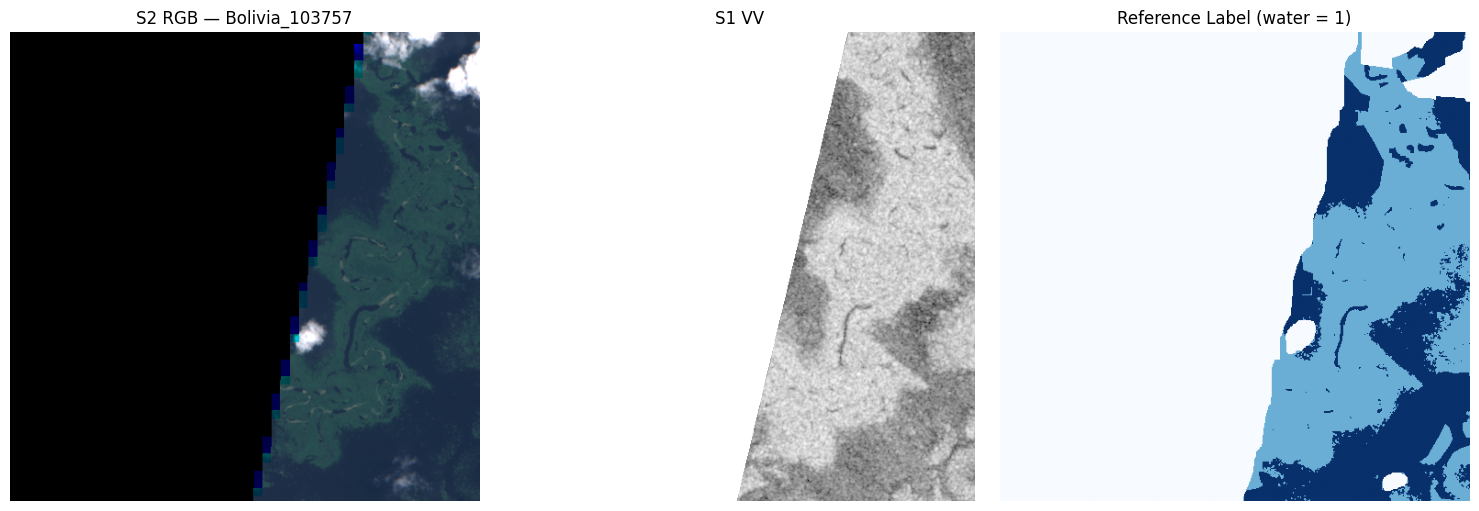

In [ ]:
from pathlib import Path
import numpy as np, rasterio
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("/content/drive/MyDrive/S1S2_Fusion_Project")

s1_files = sorted(PROJECT_ROOT.rglob("*_S1Hand.tif"))
assert s1_files, "No Sen1Floods11 S1 files found inside S1S2_Fusion_Project."

s1_file = s1_files[0]
chip_id = s1_file.name.replace("_S1Hand.tif", "")

s2_file = next(PROJECT_ROOT.rglob(f"{chip_id}_S2Hand.tif"))
label_file = next(PROJECT_ROOT.rglob(f"{chip_id}_LabelHand.tif"))

with rasterio.open(s1_file) as src:
    s1 = src.read().astype(np.float32)

with rasterio.open(s2_file) as src:
    s2 = src.read().astype(np.float32)

with rasterio.open(label_file) as src:
    label = src.read(1).astype(np.float32)

rgb = np.clip(np.stack([s2[3], s2[2], s2[1]], axis=-1) / 3000, 0, 1)

fig, ax = plt.subplots(1, 3, figsize=(15, 5))
ax[0].imshow(rgb); ax[0].set_title(f"S2 RGB — {chip_id}"); ax[0].axis("off")
ax[1].imshow(s1[0], cmap="gray"); ax[1].set_title("S1 VV"); ax[1].axis("off")
ax[2].imshow(label, cmap="Blues"); ax[2].set_title("Reference Label (water = 1)"); ax[2].axis("off")
plt.tight_layout()
plt.show()

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader


def compute_water_indices(b3, b8, b11, eps=1e-6):
    ndwi = (b3 - b8) / (b3 + b8 + eps)
    mndwi = (b3 - b11) / (b3 + b11 + eps)
    return ndwi, mndwi


class Sen1Floods11Dataset(Dataset):
    """
    No-data-aware dataset for future training.

    Invalid pixels are zeroed in the inputs and excluded from
    loss and metric calculations through valid_mask.
    """

    def __init__(self, chip_ids, s1_dir, s2_dir, label_dir):
        self.chip_ids = chip_ids
        self.s1_dir = s1_dir
        self.s2_dir = s2_dir
        self.label_dir = label_dir

    def __len__(self):
        return len(self.chip_ids)

    def __getitem__(self, idx):
        cid = self.chip_ids[idx]

        with rasterio.open(f"{self.s1_dir}/{cid}_S1Hand.tif") as f:
            s1 = f.read().astype(np.float32)

        with rasterio.open(f"{self.s2_dir}/{cid}_S2Hand.tif") as f:
            s2_full = f.read().astype(np.float32)

        with rasterio.open(f"{self.label_dir}/{cid}_LabelHand.tif") as f:
            label = f.read(1).astype(np.float32)

        s1_valid = np.any(np.isfinite(s1) & (s1 != 0), axis=0)
        s2_valid = np.any(np.isfinite(s2_full) & (s2_full != 0), axis=0)
        label_valid = np.isfinite(label) & (label != -1)

        valid_mask = (s1_valid & s2_valid & label_valid).astype(np.float32)

        vv = s1[0]
        vh = s1[1]

        s1_out = np.stack([vv, vh, vv - vh], axis=0)
        s1_out = np.nan_to_num(
            s1_out,
            nan=0.0,
            posinf=0.0,
            neginf=-50.0,
        )
        s1_out = np.clip(s1_out, -50, 0) / -50.0

        s2_full = s2_full / 10000.0

        b2 = s2_full[1]
        b3 = s2_full[2]
        b4 = s2_full[3]
        b8 = s2_full[7]
        b11 = s2_full[11]
        b12 = s2_full[12]

        ndwi, mndwi = compute_water_indices(b3, b8, b11)

        s2_out = np.stack(
            [b2, b3, b4, b8, b11, b12, ndwi, mndwi],
            axis=0,
        )
        s2_out = np.nan_to_num(
            s2_out,
            nan=0.0,
            posinf=0.0,
            neginf=0.0,
        )

        s1_out[:, valid_mask == 0] = 0.0
        s2_out[:, valid_mask == 0] = 0.0

        label = np.where(label_valid, np.clip(label, 0, 1), 0.0)

        return (
            torch.from_numpy(s2_out.astype(np.float32)),
            torch.from_numpy(s1_out.astype(np.float32)),
            torch.from_numpy(label.astype(np.float32)).unsqueeze(0),
            torch.from_numpy(valid_mask.astype(np.float32)).unsqueeze(0),
        )

In [ ]:
import torch.nn.functional as F

def dice_loss(logits, targets, valid_mask, eps=1e-6):
    probs = torch.sigmoid(logits) * valid_mask
    targets = targets * valid_mask
    probs, targets = probs.flatten(1), targets.flatten(1)
    intersection = (probs * targets).sum(1)
    union = probs.sum(1) + targets.sum(1)
    return 1 - ((2 * intersection + eps) / (union + eps)).mean()

def combined_loss(logits, targets, valid_mask):
    bce = F.binary_cross_entropy_with_logits(logits, targets, reduction="none")
    bce = (bce * valid_mask).sum() / valid_mask.sum().clamp(min=1.0)
    return bce + dice_loss(logits, targets, valid_mask)

In [ ]:
import os
import re
import random
from collections import defaultdict
from torch.utils.data import DataLoader

s1_dir = "/content/drive/MyDrive/sen1floods11/S1Hand"
s2_dir = "/content/drive/MyDrive/sen1floods11/S2Hand"
label_dir = "/content/drive/MyDrive/sen1floods11/LabelHand"

SPLIT_SEED = 42

def event_from_chip_id(chip_id):
    """Remove the final numeric chip index; inspect printed events after first run."""
    return re.sub(r"_\d+$", "", chip_id)

all_ids = sorted(
    filename.replace("_S1Hand.tif", "")
    for filename in os.listdir(s1_dir)
    if filename.endswith("_S1Hand.tif")
    and os.path.exists(os.path.join(s2_dir, filename.replace("_S1Hand.tif", "_S2Hand.tif")))
    and os.path.exists(os.path.join(label_dir, filename.replace("_S1Hand.tif", "_LabelHand.tif")))
)

if not all_ids:
    raise RuntimeError("No matched S1, S2, and label chips found.")

event_to_ids = defaultdict(list)
for chip_id in all_ids:
    event_to_ids[event_from_chip_id(chip_id)].append(chip_id)

events = sorted(event_to_ids)
rng = random.Random(SPLIT_SEED)
rng.shuffle(events)

n_events = len(events)
n_train_events = int(0.70 * n_events)
n_val_events = int(0.15 * n_events)

train_events = events[:n_train_events]
val_events = events[n_train_events:n_train_events + n_val_events]
test_events = events[n_train_events + n_val_events:]

train_ids = sorted(chip_id for event in train_events for chip_id in event_to_ids[event])
val_ids = sorted(chip_id for event in val_events for chip_id in event_to_ids[event])
test_ids = sorted(chip_id for event in test_events for chip_id in event_to_ids[event])

assert set(train_events).isdisjoint(val_events)
assert set(train_events).isdisjoint(test_events)
assert set(val_events).isdisjoint(test_events)

print(f"Events — train: {len(train_events)}, validation: {len(val_events)}, test: {len(test_events)}")
print(f"Chips  — train: {len(train_ids)}, validation: {len(val_ids)}, test: {len(test_ids)}")
print("Train events:", train_events)
print("Validation events:", val_events)
print("Test events:", test_events)

train_ds = Sen1Floods11Dataset(train_ids, s1_dir, s2_dir, label_dir)
val_ds = Sen1Floods11Dataset(val_ids, s1_dir, s2_dir, label_dir)
test_ds = Sen1Floods11Dataset(test_ids, s1_dir, s2_dir, label_dir)

train_loader = DataLoader(train_ds, batch_size=2, shuffle=True, num_workers=0)
val_loader = DataLoader(val_ds, batch_size=2, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=2, shuffle=False, num_workers=0)

def train_one_epoch(model, loader, optimizer):
    model.train()
    total_loss = 0.0
    for s2, s1, mask, valid in loader:
        s2, s1, mask, valid = s2.to(device), s1.to(device), mask.to(device), valid.to(device)
        optimizer.zero_grad()
        logits = model(s2, s1)
        loss = combined_loss(logits, mask, valid)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * s2.size(0)
    return total_loss / len(loader.dataset)

Events — train: 7, validation: 1, test: 3
Chips  — train: 291, validation: 18, test: 137
Train events: ['Somalia', 'Mekong', 'India', 'Spain', 'Pakistan', 'Paraguay', 'Sri-Lanka']
Validation events: ['Nigeria']
Test events: ['Bolivia', 'Ghana', 'USA']


Total chips: 446
Total events: 11
Bolivia: 15 chips
Ghana: 53 chips
India: 68 chips
Mekong: 30 chips
Nigeria: 18 chips
Pakistan: 28 chips
Paraguay: 67 chips
Somalia: 26 chips
Spain: 30 chips
Sri-Lanka: 42 chips
USA: 69 chips
Mean water fraction: 0.1087
Mean invalid-label fraction: 0.1363


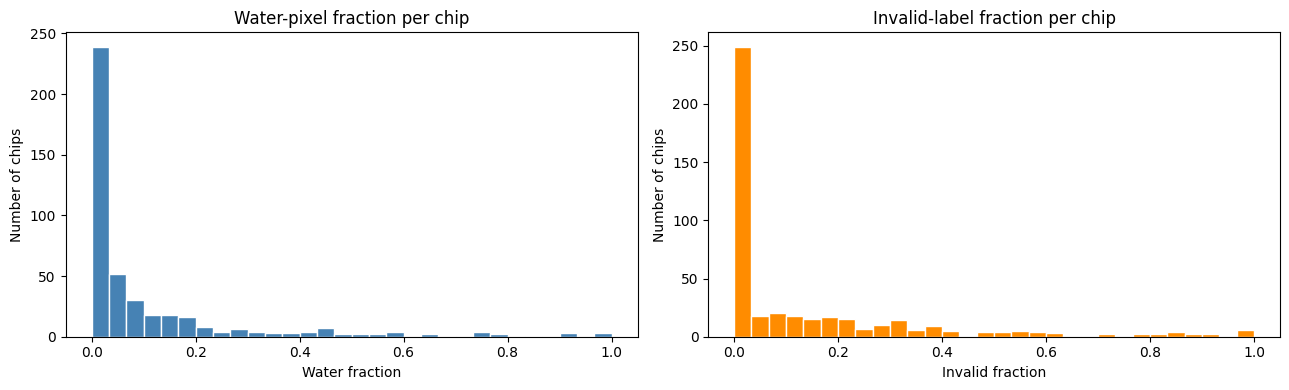

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

event_counts = Counter(event_from_chip_id(chip_id) for chip_id in all_ids)
water_fractions, invalid_fractions = [], []

for chip_id in all_ids:
    with rasterio.open(f"{label_dir}/{chip_id}_LabelHand.tif") as source:
        label = source.read(1)
    valid = label != -1
    invalid_fractions.append((~valid).mean())
    if valid.any():
        water_fractions.append((label[valid] == 1).mean())

print(f"Total chips: {len(all_ids)}")
print(f"Total events: {len(event_counts)}")
for event, count in sorted(event_counts.items()):
    print(f"{event}: {count} chips")
print(f"Mean water fraction: {np.mean(water_fractions):.4f}")
print(f"Mean invalid-label fraction: {np.mean(invalid_fractions):.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(water_fractions, bins=30, color="steelblue", edgecolor="white")
axes[0].set(title="Water-pixel fraction per chip", xlabel="Water fraction", ylabel="Number of chips")
axes[1].hist(invalid_fractions, bins=30, color="darkorange", edgecolor="white")
axes[1].set(title="Invalid-label fraction per chip", xlabel="Invalid fraction", ylabel="Number of chips")
plt.tight_layout()
plt.show()

In [ ]:
def compute_iou(logits, targets, valid_mask, threshold=0.5):
    preds = (torch.sigmoid(logits) > threshold).float() * valid_mask
    targets = targets * valid_mask
    preds, targets = preds.flatten(1), targets.flatten(1)
    intersection = (preds * targets).sum(1)
    union = (preds + targets - preds * targets).sum(1)
    return (intersection / union.clamp(min=1e-6)).mean().item()

def evaluate(model, loader):
    model.eval()
    total_loss, total_iou = 0.0, 0.0
    with torch.no_grad():
        for s2, s1, mask, valid in loader:
            s2, s1, mask, valid = s2.to(device), s1.to(device), mask.to(device), valid.to(device)
            logits = model(s2, s1)
            loss = combined_loss(logits, mask, valid)
            iou = compute_iou(logits, mask, valid)
            total_loss += loss.item() * s2.size(0)
            total_iou += iou * s2.size(0)
    n = len(loader.dataset)
    return total_loss / n, total_iou / n

val_ds = Sen1Floods11Dataset(val_ids, s1_dir, s2_dir, label_dir)
val_loader = DataLoader(val_ds, batch_size=2, shuffle=False, num_workers=0)

In [ ]:
import os
from pathlib import Path

checkpoint_files = sorted(Path(CHECKPOINT_DIR).glob("*.pth"))

print(f"Found {len(checkpoint_files)} checkpoint files:\n")

for path in checkpoint_files:
    checkpoint = torch.load(path, map_location="cpu")
    print(
        f"{path.name} | "
        f"best epoch={checkpoint['epoch']} | "
        f"best val IoU={checkpoint['best_iou']:.4f}"
    )

Found 24 checkpoint files:

early_concat_seed_123.pth | best epoch=15 | best val IoU=0.4989
early_concat_seed_42.pth | best epoch=15 | best val IoU=0.4959
early_concat_seed_7.pth | best epoch=15 | best val IoU=0.4938
full_bidirectional_pretrained_seed_123.pth | best epoch=14 | best val IoU=0.4941
full_bidirectional_pretrained_seed_42.pth | best epoch=14 | best val IoU=0.5136
full_bidirectional_pretrained_seed_7.pth | best epoch=15 | best val IoU=0.5062
full_bidirectional_random_init_seed_123.pth | best epoch=14 | best val IoU=0.4598
full_bidirectional_random_init_seed_42.pth | best epoch=14 | best val IoU=0.4666
full_bidirectional_random_init_seed_7.pth | best epoch=10 | best val IoU=0.4641
late_average_seed_123.pth | best epoch=10 | best val IoU=0.5120
late_average_seed_42.pth | best epoch=14 | best val IoU=0.4890
late_average_seed_7.pth | best epoch=14 | best val IoU=0.5076
s1_only_seed_123.pth | best epoch=13 | best val IoU=0.3640
s1_only_seed_42.pth | best epoch=15 | best val IoU=0

In [ ]:
import gc
import pandas as pd
from pathlib import Path

RUN_SEEDS = [7, 42, 123]
N_EPOCHS = 15

COMPLETED_RUNS = {
    ("full_bidirectional_pretrained", 7),
    ("full_bidirectional_pretrained", 42),
    ("full_bidirectional_pretrained", 123),

    ("late_average", 7),
    ("late_average", 42),
    ("late_average", 123),

    ("unidirectional", 7),
    ("unidirectional", 42),
    ("unidirectional", 123),

    ("single_scale", 7),
    ("single_scale", 42),
    ("single_scale", 123),

    ("early_concat", 7),
    ("early_concat", 42),
    ("early_concat", 123),

    ("s1_only", 7),
}

all_results = []

for experiment_name, seed in sorted(COMPLETED_RUNS):
    path = checkpoint_path(experiment_name, seed)
    checkpoint = torch.load(path, map_location=device)

    model = build_model(experiment_name)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()

    test_loss, test_iou = evaluate(model, test_loader)

    all_results.append({
        "experiment": experiment_name,
        "seed": seed,
        "best_epoch": checkpoint["epoch"],
        "validation_iou": checkpoint["best_iou"],
        "test_iou": test_iou,
        "test_loss": test_loss,
    })

    print(f"Restored completed run: {experiment_name}, seed {seed}")

    del model
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def set_all_seeds(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


for experiment_name in EXPERIMENTS:
    for seed in RUN_SEEDS:

        if (experiment_name, seed) in COMPLETED_RUNS:
            continue

        print(f"\n{'=' * 70}")
        print(f"Training: {experiment_name} | Seed: {seed}")
        print(f"{'=' * 70}")

        set_all_seeds(seed)
        model = build_model(experiment_name)

        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=6e-5,
            weight_decay=1e-4,
        )

        best_iou = -float("inf")
        best_epoch = 0
        path = checkpoint_path(experiment_name, seed)

        for epoch in range(N_EPOCHS):
            train_loss = train_one_epoch(model, train_loader, optimizer)
            val_loss, val_iou = evaluate(model, val_loader)

            print(
                f"Epoch {epoch + 1:02d}: "
                f"train={train_loss:.4f} | "
                f"val_loss={val_loss:.4f} | "
                f"val_IoU={val_iou:.4f}"
            )

            if val_iou > best_iou:
                best_iou = val_iou
                best_epoch = epoch + 1
                save_checkpoint(model, optimizer, best_epoch, best_iou, path)

        checkpoint = torch.load(path, map_location=device)
        model.load_state_dict(checkpoint["model_state_dict"])
        model.eval()

        test_loss, test_iou = evaluate(model, test_loader)

        all_results.append({
            "experiment": experiment_name,
            "seed": seed,
            "best_epoch": checkpoint["epoch"],
            "validation_iou": checkpoint["best_iou"],
            "test_iou": test_iou,
            "test_loss": test_loss,
        })

        del model, optimizer
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()


results_df = pd.DataFrame(all_results)
summary_df = (
    results_df.groupby("experiment")
    .agg(
        test_iou_mean=("test_iou", "mean"),
        test_iou_std=("test_iou", "std"),
        validation_iou_mean=("validation_iou", "mean"),
        validation_iou_std=("validation_iou", "std"),
    )
    .sort_values("test_iou_mean", ascending=False)
)

display(results_df)
display(summary_df)

results_df.to_csv(
    os.path.join(RESULTS_DIR, "all_ablation_results_by_seed.csv"),
    index=False,
)

summary_df.to_csv(
    os.path.join(RESULTS_DIR, "ablation_summary_mean_std.csv"),
)

print("\nAll remaining experiments completed.")

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

[transformers] SegformerModel LOAD REPORT from: nvidia/mit-b0
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Restored completed run: early_concat, seed 7


Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

[transformers] SegformerModel LOAD REPORT from: nvidia/mit-b0
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

[transformers] SegformerModel LOAD REPORT from: nvidia/mit-b0
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Epoch 01: train=1.0745 | val_loss=0.9668 | val_IoU=0.4335
  Checkpoint saved: s2_only_seed_123.pth | epoch=1 | val_IoU=0.4335
Epoch 02: train=0.8515 | val_loss=0.8098 | val_IoU=0.4519
  Checkpoint saved: s2_only_seed_123.pth | epoch=2 | val_IoU=0.4519
Epoch 03: train=0.7579 | val_loss=0.7944 | val_IoU=0.4563
  Checkpoint saved: s2_only_seed_123.pth | epoch=3 | val_IoU=0.4563
Epoch 04: train=0.7146 | val_loss=0.6540 | val_IoU=0.4481
Epoch 05: train=0.6817 | val_loss=0.8000 | val_IoU=0.4442
Epoch 06: train=0.6411 | val_loss=0.6032 | val_IoU=0.4727
  Checkpoint saved: s2_only_seed_123.pth | epoch=6 | val_IoU=0.4727
Epoch 07: train=0.6210 | val_loss=0.5497 | val_IoU=0.4770
  Checkpoint saved: s2_only_seed_123.pth | epoch=7 | val_IoU=0.4770
Epoch 08: train=0.6014 | val_loss=0.5294 | val_IoU=0.4995
  Checkpoint saved: s2_only_seed_123.pth | epoch=8 | val_IoU=0.4995
Epoch 09: train=0.5945 | val_loss=0.5774 | val_IoU=0.4883
Epoch 10: train=0.5619 | val_loss=0.5199 | val_IoU=0.5011
  Checkpoint

,experiment,seed,best_epoch,validation_iou,test_iou,test_loss
0,early_concat,7,15,0.493761,0.575997,0.452833
1,early_concat,42,15,0.495922,0.566316,0.425870
2,early_concat,123,15,0.498922,0.589154,0.419095
3,full_bidirectional_pretrained,7,15,0.506159,0.587224,0.395278
4,full_bidirectional_pretrained,42,14,0.513567,0.577500,0.416853
5,full_bidirectional_pretrained,123,14,0.494089,0.567885,0.438910
6,late_average,7,14,0.507573,0.556949,0.424331
7,late_average,42,14,0.489038,0.557978,0.449799
8,late_average,123,10,0.512012,0.570894,0.438553
9,s1_only,7,13,0.372143,0.418077,0.646085


,test_iou_mean,test_iou_std,validation_iou_mean,validation_iou_std
experiment,,,,
full_bidirectional_pretrained,0.577536,0.009670,0.504605,0.009832
early_concat,0.577156,0.011463,0.496202,0.002592
s2_only,0.574842,0.003747,0.503270,0.008899
single_scale,0.570805,0.006868,0.505629,0.010830
late_average,0.561940,0.007771,0.502874,0.012187
unidirectional,0.548920,0.014535,0.495495,0.009632
full_bidirectional_random_init,0.533459,0.002538,0.463495,0.003419
s1_only,0.419436,0.001236,0.368920,0.004328



All remaining experiments completed.


In [ ]:
import pandas as pd
import os

results_df = pd.read_csv(
    os.path.join(RESULTS_DIR, "all_ablation_results_by_seed.csv")
)

summary_df = pd.read_csv(
    os.path.join(RESULTS_DIR, "ablation_summary_mean_std.csv"),
    index_col=0,
)

display(results_df)
display(summary_df)

,experiment,seed,best_epoch,validation_iou,test_iou,test_loss
0,early_concat,7,15,0.493761,0.575997,0.452833
1,early_concat,42,15,0.495922,0.566316,0.425870
2,early_concat,123,15,0.498922,0.589154,0.419095
3,full_bidirectional_pretrained,7,15,0.506159,0.587224,0.395278
4,full_bidirectional_pretrained,42,14,0.513567,0.577500,0.416853
5,full_bidirectional_pretrained,123,14,0.494089,0.567885,0.438910
6,late_average,7,14,0.507573,0.556949,0.424331
7,late_average,42,14,0.489038,0.557978,0.449799
8,late_average,123,10,0.512012,0.570894,0.438553
9,s1_only,7,13,0.372143,0.418077,0.646085


,test_iou_mean,test_iou_std,validation_iou_mean,validation_iou_std
experiment,,,,
full_bidirectional_pretrained,0.577536,0.009670,0.504605,0.009832
early_concat,0.577156,0.011463,0.496202,0.002592
s2_only,0.574842,0.003747,0.503270,0.008899
single_scale,0.570805,0.006868,0.505629,0.010830
late_average,0.561940,0.007771,0.502874,0.012187
unidirectional,0.548920,0.014535,0.495495,0.009632
full_bidirectional_random_init,0.533459,0.002538,0.463495,0.003419
s1_only,0.419436,0.001236,0.368920,0.004328


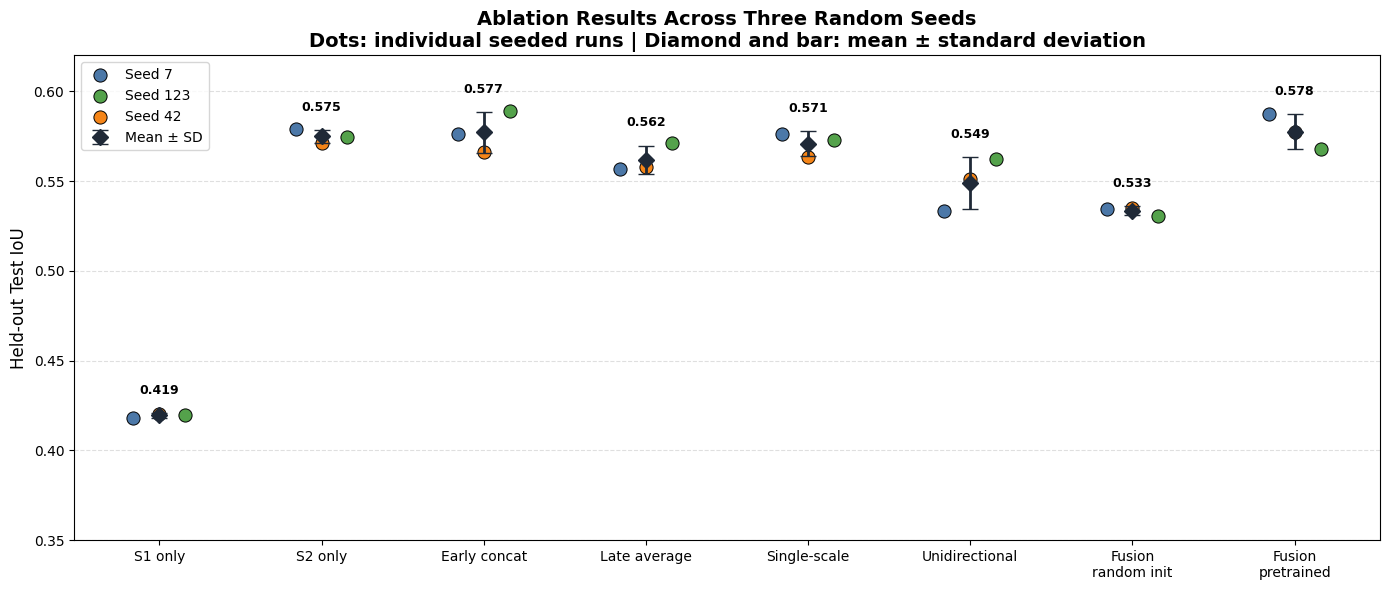

Saved figure to: /content/drive/MyDrive/S1S2_Fusion Architecture_output/figures/ablation_test_iou_three_seed_comparison.png


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

experiment_order = [
    "s1_only",
    "s2_only",
    "early_concat",
    "late_average",
    "single_scale",
    "unidirectional",
    "full_bidirectional_random_init",
    "full_bidirectional_pretrained",
]

display_names = {
    "s1_only": "S1 only",
    "s2_only": "S2 only",
    "early_concat": "Early concat",
    "late_average": "Late average",
    "single_scale": "Single-scale",
    "unidirectional": "Unidirectional",
    "full_bidirectional_random_init": "Fusion\nrandom init",
    "full_bidirectional_pretrained": "Fusion\npretrained",
}

seed_colors = {
    7: "#4C78A8",
    42: "#F58518",
    123: "#54A24B",
}

plot_df = results_df.copy()
plot_df["experiment"] = pd.Categorical(
    plot_df["experiment"],
    categories=experiment_order,
    ordered=True,
)
plot_df = plot_df.sort_values("experiment")

fig, ax = plt.subplots(figsize=(14, 6))

x_positions = np.arange(len(experiment_order))
offsets = {7: -0.16, 42: 0.00, 123: 0.16}

for i, experiment in enumerate(experiment_order):
    exp_data = plot_df[plot_df["experiment"] == experiment]

    for _, row in exp_data.iterrows():
        seed = int(row["seed"])
        ax.scatter(
            i + offsets[seed],
            row["test_iou"],
            s=90,
            color=seed_colors[seed],
            edgecolor="black",
            linewidth=0.7,
            zorder=3,
            label=f"Seed {seed}" if i == 0 else None,
        )

    mean_iou = exp_data["test_iou"].mean()
    std_iou = exp_data["test_iou"].std(ddof=1)

    ax.errorbar(
        i,
        mean_iou,
        yerr=std_iou,
        fmt="D",
        markersize=8,
        color="#1F2937",
        capsize=6,
        linewidth=2,
        zorder=4,
        label="Mean ± SD" if i == 0 else None,
    )

    ax.text(
        i,
        mean_iou + std_iou + 0.009,
        f"{mean_iou:.3f}",
        ha="center",
        va="bottom",
        fontsize=9,
        fontweight="bold",
    )

ax.set_xticks(x_positions)
ax.set_xticklabels(
    [display_names[name] for name in experiment_order],
    fontsize=10,
)
ax.set_ylabel("Held-out Test IoU", fontsize=12)
ax.set_title(
    "Ablation Results Across Three Random Seeds\n"
    "Dots: individual seeded runs | Diamond and bar: mean ± standard deviation",
    fontsize=14,
    fontweight="bold",
)
ax.set_ylim(0.35, 0.62)
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(loc="upper left", frameon=True)

plt.tight_layout()

output_path = os.path.join(
    FIGURES_DIR,
    "ablation_test_iou_three_seed_comparison.png",
)
plt.savefig(output_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved figure to:", output_path)

In [ ]:
EXPERIMENT_TO_LOAD = "full_bidirectional_pretrained"
SEED_TO_LOAD = 42

model = build_model(EXPERIMENT_TO_LOAD)

saved = torch.load(
    checkpoint_path(EXPERIMENT_TO_LOAD, SEED_TO_LOAD),
    map_location=device,
)

model.load_state_dict(saved["model_state_dict"])
model.eval()

print(
    f"Loaded {EXPERIMENT_TO_LOAD}, seed {SEED_TO_LOAD} | "
    f"best epoch={saved['epoch']} | "
    f"best validation IoU={saved['best_iou']:.4f}"
)

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

[transformers] SegformerModel LOAD REPORT from: nvidia/mit-b0
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

[transformers] SegformerModel LOAD REPORT from: nvidia/mit-b0
Key               | Status     |  | 
------------------+------------+--+-
classifier.bias   | UNEXPECTED |  | 
classifier.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loaded full_bidirectional_pretrained, seed 42 | best epoch=14 | best validation IoU=0.5136


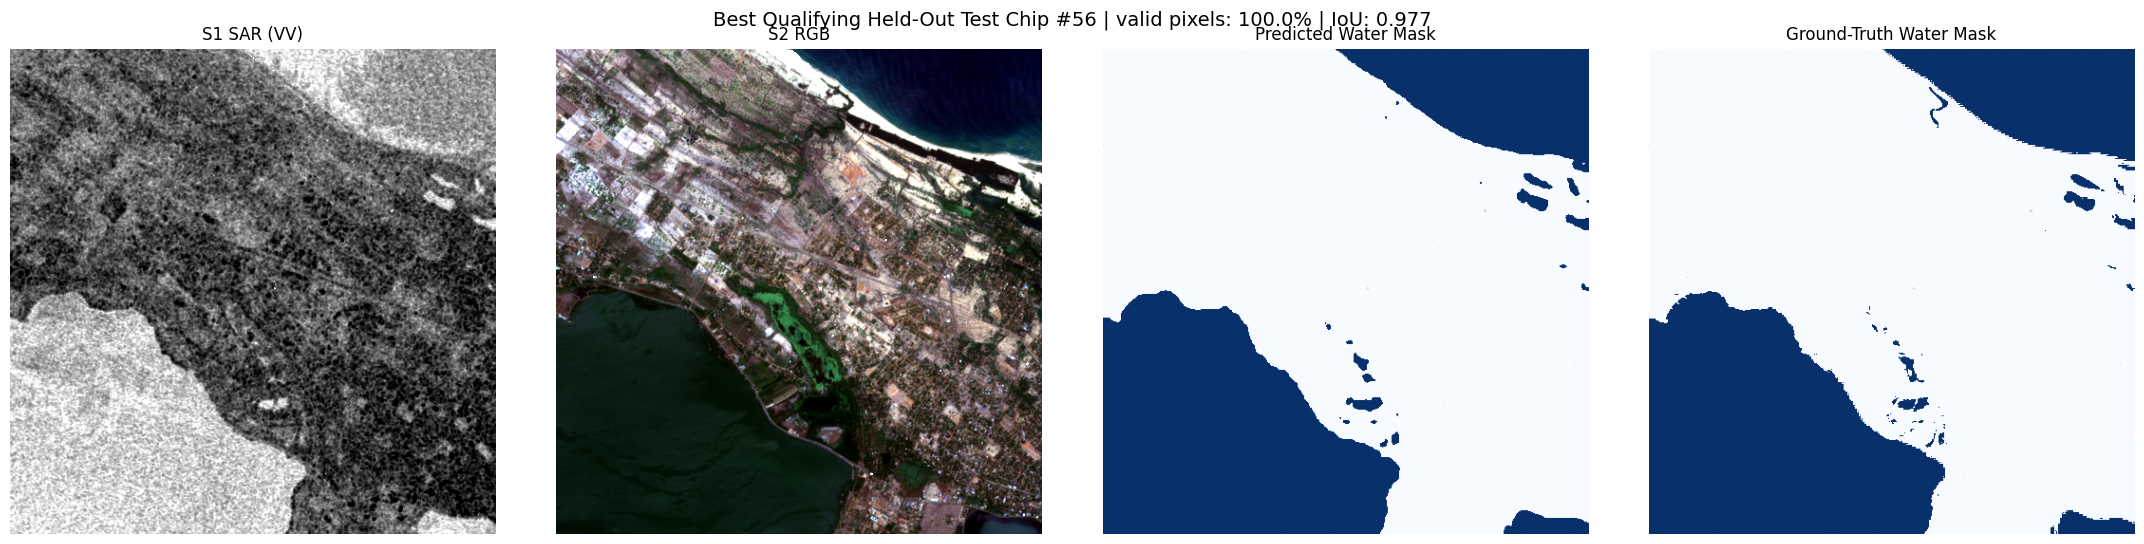

Saved: /content/drive/MyDrive/S1S2_Fusion Architecture_output/figures/best_test_chip_s1_s2_prediction_seed42.png


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

candidate_results = []

model.eval()

with torch.no_grad():
    for i in range(len(test_ds)):
        s2_i, s1_i, mask_i, valid_i = test_ds[i]

        valid_i_np = valid_i.squeeze().numpy().astype(bool)
        truth_i = mask_i.squeeze().numpy()

        if valid_i_np.mean() < 0.95:
            continue

        water_fraction_i = truth_i[valid_i_np].mean()

        if water_fraction_i < 0.02:
            continue

        logits_i = model(
            s2_i.unsqueeze(0).to(device),
            s1_i.unsqueeze(0).to(device),
        )

        pred_i = (
            torch.sigmoid(logits_i) > 0.5
        ).float().squeeze().cpu().numpy()

        intersection = np.sum(
            (pred_i == 1) & (truth_i == 1) & valid_i_np
        )
        union = np.sum(
            ((pred_i == 1) | (truth_i == 1)) & valid_i_np
        )

        chip_iou_i = intersection / (union + 1e-9)
        candidate_results.append((chip_iou_i, i, water_fraction_i))

if not candidate_results:
    raise RuntimeError("No suitable valid water-containing test chip found.")

candidate_results.sort(reverse=True)
chip_iou, sample_index, water_fraction = candidate_results[0]

s2_sample, s1_sample, mask_sample, valid_sample = test_ds[sample_index]

with torch.no_grad():
    logits = model(
        s2_sample.unsqueeze(0).to(device),
        s1_sample.unsqueeze(0).to(device),
    )

pred = (
    torch.sigmoid(logits) > 0.5
).float().squeeze().cpu().numpy()

valid_np = valid_sample.squeeze().numpy().astype(bool)
ground_truth = mask_sample.squeeze().numpy()

s1_vv = s1_sample[0].numpy()
s1_display = np.zeros_like(s1_vv)

s1_values = s1_vv[valid_np]
low, high = np.percentile(s1_values, [2, 98])

s1_display = np.clip(
    (s1_vv - low) / (high - low + 1e-8),
    0,
    1,
)
s1_display[~valid_np] = np.nan

s2_np = s2_sample.numpy()
rgb = np.stack([s2_np[2], s2_np[1], s2_np[0]], axis=-1)

rgb_display = np.zeros_like(rgb)

for channel in range(3):
    values = rgb[:, :, channel][valid_np]
    low, high = np.percentile(values, [2, 98])

    rgb_display[:, :, channel] = np.clip(
        (rgb[:, :, channel] - low) / (high - low + 1e-8),
        0,
        1,
    )

rgb_display[~valid_np] = np.nan

pred_display = np.ma.masked_where(~valid_np, pred)
truth_display = np.ma.masked_where(~valid_np, ground_truth)

mask_cmap = plt.cm.Blues.copy()
mask_cmap.set_bad("lightgray")

fig, axes = plt.subplots(1, 4, figsize=(22, 5.5))

axes[0].imshow(s1_display, cmap="gray", vmin=0, vmax=1)
axes[0].set_title("S1 SAR (VV)")

axes[1].imshow(rgb_display)
axes[1].set_title("S2 RGB")

axes[2].imshow(pred_display, cmap=mask_cmap, vmin=0, vmax=1)
axes[2].set_title("Predicted Water Mask")

axes[3].imshow(truth_display, cmap=mask_cmap, vmin=0, vmax=1)
axes[3].set_title("Ground-Truth Water Mask")

for axis in axes:
    axis.axis("off")

plt.suptitle(
    f"Best Qualifying Held-Out Test Chip #{sample_index} | "
    f"valid pixels: {valid_np.mean():.1%} | IoU: {chip_iou:.3f}",
    fontsize=14,
)

plt.tight_layout()

output_path = os.path.join(
    FIGURES_DIR,
    "best_test_chip_s1_s2_prediction_seed42.png",
)

plt.savefig(output_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", output_path)

In [ ]:
!pip install -q earthengine-api
import ee
ee.Authenticate()

In [ ]:
import ee

try:
    ee.Initialize(project='thermal-circle-501517-e2')
    print("Earth Engine initialized successfully!")
except Exception as e:
    print("Error:", e)

Earth Engine initialized successfully!


In [ ]:
import rasterio
from rasterio.windows import Window
import numpy as np
import torch

TILE = 512

def preprocess_s2_tile(s2_tile):
    s2_tile = s2_tile.astype(np.float32) / 10000.0
    b2, b3, b4, b8, b11, b12 = s2_tile[0], s2_tile[1], s2_tile[2], s2_tile[3], s2_tile[4], s2_tile[5]
    eps = 1e-6
    ndwi = (b3 - b8) / (b3 + b8 + eps)
    mndwi = (b3 - b11) / (b3 + b11 + eps)
    output = np.stack([b2, b3, b4, b8, b11, b12, ndwi, mndwi], axis=0)
    return np.nan_to_num(output, nan=0.0, posinf=0.0, neginf=0.0).astype(np.float32)

def preprocess_s1_tile(s1_tile):
    vv, vh = s1_tile[0], s1_tile[1]
    output = np.stack([vv, vh, vv - vh], axis=0)
    output = np.nan_to_num(output, nan=0.0, posinf=0.0, neginf=-50.0)
    return (np.clip(output, -50, 0) / -50.0).astype(np.float32)

def run_tiled_inference(s2_path, s1_path, model, device, tile_size=512, stride=256, threshold=0.5):
    """Returns prediction (-1=no-data, 0=non-water, 1=water) and mean probability."""
    assert 0 < stride <= tile_size
    with rasterio.open(s2_path) as s2_src, rasterio.open(s1_path) as s1_src:
        if (s2_src.height, s2_src.width) != (s1_src.height, s1_src.width):
            raise ValueError("S1 and S2 must have the same raster dimensions.")
        height, width = s2_src.height, s2_src.width
        probability_sum = np.zeros((height, width), dtype=np.float32)
        prediction_count = np.zeros((height, width), dtype=np.float32)
        valid_any = np.zeros((height, width), dtype=bool)

        y_starts = list(range(0, max(height - tile_size, 0) + 1, stride))
        x_starts = list(range(0, max(width - tile_size, 0) + 1, stride))
        if y_starts[-1] != max(height - tile_size, 0): y_starts.append(max(height - tile_size, 0))
        if x_starts[-1] != max(width - tile_size, 0): x_starts.append(max(width - tile_size, 0))

        model.eval()
        total, count = len(y_starts) * len(x_starts), 0
        with torch.no_grad():
            for ty in y_starts:
                for tx in x_starts:
                    h, w = min(tile_size, height - ty), min(tile_size, width - tx)
                    window = Window(tx, ty, w, h)
                    s2_tile = s2_src.read(window=window).astype(np.float32)
                    s1_tile = s1_src.read(window=window).astype(np.float32)
                    valid_pixels = (np.any(np.isfinite(s2_tile) & (s2_tile != 0), axis=0) &
                                    np.any(np.isfinite(s1_tile) & (s1_tile != 0), axis=0))
                    if valid_pixels.any():
                        s2_pad = np.zeros((s2_tile.shape[0], tile_size, tile_size), dtype=np.float32)
                        s1_pad = np.zeros((s1_tile.shape[0], tile_size, tile_size), dtype=np.float32)
                        s2_pad[:, :h, :w], s1_pad[:, :h, :w] = s2_tile, s1_tile
                        s2_t = torch.from_numpy(preprocess_s2_tile(s2_pad)).unsqueeze(0).to(device)
                        s1_t = torch.from_numpy(preprocess_s1_tile(s1_pad)).unsqueeze(0).to(device)
                        probabilities = torch.sigmoid(model(s2_t, s1_t)).squeeze().cpu().numpy()[:h, :w]
                        probability_sum[ty:ty+h, tx:tx+w] += probabilities * valid_pixels
                        prediction_count[ty:ty+h, tx:tx+w] += valid_pixels
                        valid_any[ty:ty+h, tx:tx+w] |= valid_pixels
                    count += 1
                    if count % 20 == 0 or count == total:
                        print(f"Processed {count}/{total} tiles")

    mean_probability = probability_sum / np.maximum(prediction_count, 1)
    prediction = (mean_probability >= threshold).astype(np.int16)
    prediction[~valid_any] = -1
    print(f"No-data pixels excluded before thresholding: {(~valid_any).sum()}")
    return prediction, mean_probability

In [ ]:
mahanadi_s2_path = "/content/drive/MyDrive/S1S2_Fusion_Project/regions/mahanadi_basin/raw/S2/mahanadi_s2.tif"
mahanadi_s1_path = "/content/drive/MyDrive/S1S2_Fusion_Project/regions/mahanadi_basin/raw/S1/mahanadi_s1_v4.tif"

mahanadi_pred, mahanadi_probability = run_tiled_inference(
    mahanadi_s2_path, mahanadi_s1_path, model, device, tile_size=512, stride=256
)

Processed 20/1326 tiles
Processed 40/1326 tiles
Processed 60/1326 tiles
Processed 80/1326 tiles
Processed 100/1326 tiles
Processed 120/1326 tiles
Processed 140/1326 tiles
Processed 160/1326 tiles
Processed 180/1326 tiles
Processed 200/1326 tiles
Processed 220/1326 tiles
Processed 240/1326 tiles
Processed 260/1326 tiles
Processed 280/1326 tiles
Processed 300/1326 tiles
Processed 320/1326 tiles
Processed 340/1326 tiles
Processed 360/1326 tiles
Processed 380/1326 tiles
Processed 400/1326 tiles
Processed 420/1326 tiles
Processed 440/1326 tiles
Processed 460/1326 tiles
Processed 480/1326 tiles
Processed 500/1326 tiles
Processed 520/1326 tiles
Processed 540/1326 tiles
Processed 560/1326 tiles
Processed 580/1326 tiles
Processed 600/1326 tiles
Processed 620/1326 tiles
Processed 640/1326 tiles
Processed 660/1326 tiles
Processed 680/1326 tiles
Processed 700/1326 tiles
Processed 720/1326 tiles
Processed 740/1326 tiles
Processed 760/1326 tiles
Processed 780/1326 tiles
Processed 800/1326 tiles
Proc

In [ ]:
import rasterio

def check_alignment(s2_path, s1_path):
    with rasterio.open(s2_path) as s2, rasterio.open(s1_path) as s1:
        print("S2 shape:", s2.height, s2.width)
        print("S1 shape:", s1.height, s1.width)
        print("Same CRS:", s2.crs == s1.crs)
        print("Same transform:", s2.transform == s1.transform)
        print("S2 CRS:", s2.crs)
        print("S1 CRS:", s1.crs)

check_alignment(mahanadi_s2_path, mahanadi_s1_path)

S2 shape: 8913 10020
S1 shape: 8913 10020
Same CRS: True
Same transform: True
S2 CRS: EPSG:4326
S1 CRS: EPSG:4326


In [ ]:
mahanadi_output_path = os.path.join(
    INFERENCE_DIR,
    "mahanadi_water_prediction_seed42.tif",
)

with rasterio.open(mahanadi_s2_path) as src:
    profile = src.profile.copy()

profile.update(
    count=1,
    dtype=rasterio.int16,
    nodata=-1,
    compress="lzw",
)

with rasterio.open(mahanadi_output_path, "w", **profile) as dst:
    dst.write(mahanadi_pred.astype(np.int16), 1)

print("Saved:", mahanadi_output_path)

Saved: /content/drive/MyDrive/S1S2_Fusion Architecture_output/inference/mahanadi_water_prediction_seed42.tif


In [ ]:
tungabhadra_s2_path = "/content/drive/MyDrive/S1S2_Fusion_Project/regions/tungabhadra_reservoir/raw/S2/tungabhadra_s2.tif"
tungabhadra_s1_path = "/content/drive/MyDrive/S1S2_Fusion_Project/regions/tungabhadra_reservoir/raw/S1/tungabhadra_s1_v2b.tif"

tungabhadra_pred, tungabhadra_probability = run_tiled_inference(
    tungabhadra_s2_path, tungabhadra_s1_path, model, device, tile_size=512, stride=256
)

Processed 20/104 tiles
Processed 40/104 tiles
Processed 60/104 tiles
Processed 80/104 tiles
Processed 100/104 tiles
Processed 104/104 tiles
No-data pixels excluded before thresholding: 1034050


In [ ]:
tungabhadra_output_path = os.path.join(
    INFERENCE_DIR,
    "tungabhadra_water_prediction_seed42.tif",
)

with rasterio.open(tungabhadra_s2_path) as src:
    profile = src.profile.copy()

profile.update(
    count=1,
    dtype=rasterio.int16,
    nodata=-1,
    compress="lzw",
)

with rasterio.open(tungabhadra_output_path, "w", **profile) as dst:
    dst.write(tungabhadra_pred.astype(np.int16), 1)

print("Saved:", tungabhadra_output_path)

Saved: /content/drive/MyDrive/S1S2_Fusion Architecture_output/inference/tungabhadra_water_prediction_seed42.tif


In [ ]:
import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt


def percentile_stretch(image, valid_mask, low_percentile=2, high_percentile=98):
    """Contrast-stretch a single image using valid pixels only."""
    output = np.zeros_like(image, dtype=np.float32)

    values = image[valid_mask & np.isfinite(image)]

    if len(values) == 0:
        return output

    low, high = np.percentile(values, [low_percentile, high_percentile])

    output = np.clip(
        (image - low) / (high - low + 1e-8),
        0,
        1,
    )

    return output


def show_s1_s2_fusion_prediction(
    s1_path,
    s2_path,
    pred_mask,
    title,
    output_path,
):
    with rasterio.open(s1_path) as s1_src:
        s1_vv = s1_src.read(1).astype(np.float32)

    with rasterio.open(s2_path) as s2_src:
        s2 = s2_src.read([3, 2, 1]).astype(np.float32)

    s1_valid = np.isfinite(s1_vv) & (s1_vv != 0)
    s2_valid = (
        np.all(np.isfinite(s2), axis=0)
        & np.any(s2 != 0, axis=0)
    )

    valid = s1_valid & s2_valid & (pred_mask != -1)

    if not valid.any():
        raise RuntimeError(f"{title}: no valid pixels available.")

    rows, cols = np.where(valid)
    r0, r1 = rows.min(), rows.max() + 1
    c0, c1 = cols.min(), cols.max() + 1

    valid_crop = valid[r0:r1, c0:c1]

    # S1 display
    s1_crop = s1_vv[r0:r1, c0:c1]
    s1_display = percentile_stretch(s1_crop, valid_crop)
    s1_display[~valid_crop] = np.nan

    # S2 RGB display
    s2_crop = s2[:, r0:r1, c0:c1]
    rgb = np.transpose(s2_crop, (1, 2, 0))

    rgb_display = np.zeros_like(rgb, dtype=np.float32)

    for channel in range(3):
        rgb_display[:, :, channel] = percentile_stretch(
            rgb[:, :, channel],
            valid_crop,
        )

    rgb_display[~valid_crop] = np.nan

    # Fusion-model prediction
    pred_crop = pred_mask[r0:r1, c0:c1]
    pred_display = np.ma.masked_where(
        (~valid_crop) | (pred_crop == -1),
        pred_crop,
    )

    water_cmap = plt.cm.Blues.copy()
    water_cmap.set_bad("lightgray")

    fig, axes = plt.subplots(1, 3, figsize=(19, 7))

    axes[0].imshow(s1_display, cmap="gray", vmin=0, vmax=1)
    axes[0].set_title(f"{title} — S1 SAR (VV)")

    axes[1].imshow(rgb_display)
    axes[1].set_title(f"{title} — S2 RGB")

    axes[2].imshow(
        pred_display,
        cmap=water_cmap,
        vmin=0,
        vmax=1,
        interpolation="nearest",
    )
    axes[2].set_title(f"{title} — Fusion-Model Water Mask")

    for axis in axes:
        axis.axis("off")

    plt.tight_layout()
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    plt.show()

    print("Saved:", output_path)


show_s1_s2_fusion_prediction(
    mahanadi_s1_path,
    mahanadi_s2_path,
    mahanadi_pred,
    "Mahanadi Basin",
    os.path.join(
        FIGURES_DIR,
        "mahanadi_s1_s2_fusion_prediction_seed42.png",
    ),
)

show_s1_s2_fusion_prediction(
    tungabhadra_s1_path,
    tungabhadra_s2_path,
    tungabhadra_pred,
    "Tungabhadra Reservoir",
    os.path.join(
        FIGURES_DIR,
        "tungabhadra_s1_s2_fusion_prediction_seed42.png",
    ),
)

In [ ]:
import rasterio
import numpy as np
import torch

BASE_DIR = "/content/drive/MyDrive/sen1floods11"

print(f"Held-out test chips: {len(test_ids)}")

def load_chip(chip_id):
    with rasterio.open(f"{BASE_DIR}/S1Hand/{chip_id}_S1Hand.tif") as src:
        s1 = src.read().astype(np.float32)

    with rasterio.open(f"{BASE_DIR}/S2Hand/{chip_id}_S2Hand.tif") as src:
        s2 = src.read().astype(np.float32)

    with rasterio.open(f"{BASE_DIR}/LabelHand/{chip_id}_LabelHand.tif") as src:
        label = src.read(1).astype(np.float32)

    return s1, s2, label


def preprocess_s2_full(s2_full):
    s2_full = s2_full / 10000.0
    b2, b3, b4, b8, b11, b12 = (
        s2_full[1], s2_full[2], s2_full[3],
        s2_full[7], s2_full[11], s2_full[12],
    )

    eps = 1e-6
    ndwi = (b3 - b8) / (b3 + b8 + eps)
    mndwi = (b3 - b11) / (b3 + b11 + eps)

    output = np.stack(
        [b2, b3, b4, b8, b11, b12, ndwi, mndwi],
        axis=0,
    )

    return np.nan_to_num(
        output,
        nan=0.0,
        posinf=0.0,
        neginf=0.0,
    ).astype(np.float32)


def preprocess_s1_full(s1_full):
    vv, vh = s1_full[0], s1_full[1]

    output = np.stack([vv, vh, vv - vh], axis=0)
    output = np.nan_to_num(
        output,
        nan=0.0,
        posinf=0.0,
        neginf=-50.0,
    )

    return (np.clip(output, -50, 0) / -50.0).astype(np.float32)

Held-out test chips: 68


Macro IoU: 0.5775
Median per-chip IoU: 0.6340
Per-chip IoU standard deviation: 0.2812
Micro IoU: 0.8312


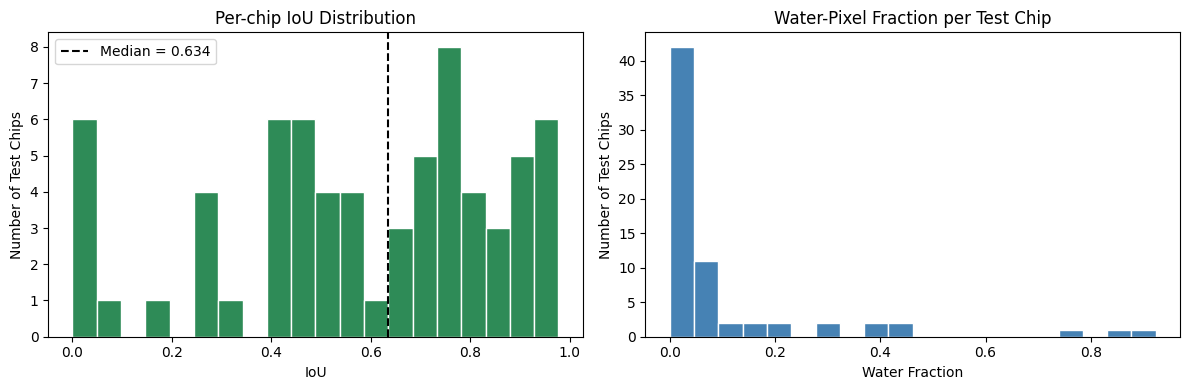

Saved: /content/drive/MyDrive/S1S2_Fusion Architecture_output/figures/per_chip_iou_distribution_seed42.png


In [ ]:
TP = FP = FN = TN = 0
per_chip_ious = []
water_fractions = []

model.eval()

with torch.no_grad():
    for chip_id in test_ids:
        s1, s2, label = load_chip(chip_id)

        s2_tensor = torch.from_numpy(
            preprocess_s2_full(s2)
        ).unsqueeze(0).to(device)

        s1_tensor = torch.from_numpy(
            preprocess_s1_full(s1)
        ).unsqueeze(0).to(device)

        prediction = (
            torch.sigmoid(model(s2_tensor, s1_tensor)) > 0.5
        ).float().squeeze().cpu().numpy()

        valid = label != -1
        pred_valid = prediction[valid]
        label_valid = label[valid]

        tp = np.sum((pred_valid == 1) & (label_valid == 1))
        fp = np.sum((pred_valid == 1) & (label_valid == 0))
        fn = np.sum((pred_valid == 0) & (label_valid == 1))
        tn = np.sum((pred_valid == 0) & (label_valid == 0))

        TP += tp
        FP += fp
        FN += fn
        TN += tn

        per_chip_ious.append(tp / (tp + fp + fn + 1e-9))
        water_fractions.append((label_valid == 1).mean())

macro_iou = np.mean(per_chip_ious)
micro_iou = TP / (TP + FP + FN + 1e-9)

print(f"Macro IoU: {macro_iou:.4f}")
print(f"Median per-chip IoU: {np.median(per_chip_ious):.4f}")
print(f"Per-chip IoU standard deviation: {np.std(per_chip_ious, ddof=1):.4f}")
print(f"Micro IoU: {micro_iou:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(per_chip_ious, bins=20, color="seagreen", edgecolor="white")
axes[0].axvline(
    np.median(per_chip_ious),
    color="black",
    linestyle="--",
    label=f"Median = {np.median(per_chip_ious):.3f}",
)
axes[0].set_title("Per-chip IoU Distribution")
axes[0].set_xlabel("IoU")
axes[0].set_ylabel("Number of Test Chips")
axes[0].legend()

axes[1].hist(water_fractions, bins=20, color="steelblue", edgecolor="white")
axes[1].set_title("Water-Pixel Fraction per Test Chip")
axes[1].set_xlabel("Water Fraction")
axes[1].set_ylabel("Number of Test Chips")

plt.tight_layout()

per_chip_figure_path = os.path.join(
    FIGURES_DIR,
    "per_chip_iou_distribution_seed42.png",
)

plt.savefig(per_chip_figure_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", per_chip_figure_path)

In [ ]:
def evaluate_modality_corruption(model, loader, mode="none"):
    model.eval()
    ious = []

    with torch.no_grad():
        for s2, s1, mask, valid in loader:
            s2 = s2.to(device)
            s1 = s1.to(device)
            mask = mask.to(device)
            valid = valid.to(device)

            if mode == "remove_s1":
                s1 = torch.zeros_like(s1)

            elif mode == "remove_s2":
                s2 = torch.zeros_like(s2)

            elif mode == "noise_s1":
                s1 = s1 + 0.15 * torch.randn_like(s1)

            elif mode == "noise_s2":
                s2 = s2 + 0.15 * torch.randn_like(s2)

            logits = model(s2, s1)
            ious.append(compute_iou(logits, mask, valid))

    return float(np.mean(ious))


robustness_results = {}

for mode in ["none", "remove_s1", "remove_s2", "noise_s1", "noise_s2"]:
    robustness_results[mode] = evaluate_modality_corruption(
        model,
        test_loader,
        mode,
    )

baseline_iou = robustness_results["none"]

for mode, iou in robustness_results.items():
    print(
        f"{mode:10s} | "
        f"IoU={iou:.4f} | "
        f"drop={baseline_iou - iou:.4f}"
    )

pd.DataFrame(
    [
        {
            "condition": mode,
            "iou": iou,
            "iou_drop_from_clean": baseline_iou - iou,
        }
        for mode, iou in robustness_results.items()
    ]
).to_csv(
    os.path.join(RESULTS_DIR, "modality_robustness_seed42.csv"),
    index=False,
)

none       | IoU=0.5775 | drop=0.0000
remove_s1  | IoU=0.2776 | drop=0.2999
remove_s2  | IoU=0.1097 | drop=0.4678
noise_s1   | IoU=0.5687 | drop=0.0088
noise_s2   | IoU=0.3935 | drop=0.1840


In [ ]:
def preprocess_s2(arr):
    """arr: (6,H,W) B2,B3,B4,B8,B11,B12 from GEE"""
    a = arr / 10000.0
    b2,b3,b4,b8,b11,b12 = a[0],a[1],a[2],a[3],a[4],a[5]
    eps = 1e-6
    ndwi  = (b3-b8) /(b3+b8 +eps)
    mndwi = (b3-b11)/(b3+b11+eps)
    out = np.stack([b2,b3,b4,b8,b11,b12,ndwi,mndwi], axis=0)
    return np.nan_to_num(out, nan=0.0)

def preprocess_s1(arr):
    """arr: (2,H,W) VV,VH in dB from GEE"""
    vv, vh = arr[0], arr[1]
    out = np.stack([vv, vh, vv-vh], axis=0)
    out = np.nan_to_num(out, nan=-50.0, posinf=0.0, neginf=-50.0)
    return np.clip(out, -50, 0) / -50.0

def display_s1(arr):
    """Proper SAR display — percentile stretch on VV dB"""
    vv = arr[0].copy().astype(np.float32)

    med = float(np.nanmedian(vv[np.isfinite(vv)])) if np.any(np.isfinite(vv)) else -15.0
    vv  = np.nan_to_num(vv, nan=med)
    p2, p98 = np.percentile(vv, 2), np.percentile(vv, 98)
    vv  = np.clip(vv, p2, p98)
    return (vv - p2) / (p98 - p2 + 1e-8)

def display_s2(arr):
    """Natural colour RGB with percentile stretch"""
    rgb = np.stack([arr[2], arr[1], arr[0]], axis=-1).astype(np.float32)
    p2, p98 = np.percentile(rgb, 2), np.percentile(rgb, 98)
    rgb = np.clip(rgb, p2, p98)
    return (rgb - p2) / (p98 - p2 + 1e-8)

def extract_paired_patches(s1_path, s2_path, patch_size=512, n=12):
    """
    Extract n patches that are valid in BOTH S1 and S2.
    Uses a shuffled dense grid so patches are spread across the image.
    """
    with rasterio.open(s1_path) as src:
        H1, W1 = src.height, src.width
    with rasterio.open(s2_path) as src:
        H2, W2 = src.height, src.width

    step = patch_size // 2
    rows = list(range(0, H1 - patch_size, step))
    cols = list(range(0, W1 - patch_size, step))
    cands = [(r, c) for r in rows for c in cols]
    np.random.seed(42)
    np.random.shuffle(cands)

    s1_patches, s2_patches = [], []

    for (r1, c1) in cands:

        with rasterio.open(s1_path) as src:
            win1  = Window(c1, r1, patch_size, patch_size)
            s1_arr = src.read(window=win1).astype(np.float32)


        r2 = min(int(r1 * H2 / H1), H2 - patch_size)
        c2 = min(int(c1 * W2 / W1), W2 - patch_size)
        with rasterio.open(s2_path) as src:
            win2  = Window(c2, r2, patch_size, patch_size)
            s2_arr = src.read(window=win2).astype(np.float32)

        s1_ok = (np.isfinite(s1_arr) & (s1_arr != 0)).mean() > 0.7
        s2_ok = (np.isfinite(s2_arr) & (s2_arr != 0)).mean() > 0.7
        if not (s1_ok and s2_ok):
            continue

        s1_patches.append(s1_arr)
        s2_patches.append(s2_arr)
        if len(s1_patches) == n:
            break

    print(f"  Extracted {len(s1_patches)} valid paired patches")
    return s1_patches, s2_patches

print("Preprocessing functions defined.")

Preprocessing functions defined.


In [ ]:
class SegGradCAM:
    """
    GradCAM for segmentation.
    Hooks onto model.decoder.fuse — the layer just before the
    final prediction head. This gives much stronger, more
    spatially meaningful gradients than hooking deep attention layers.
    """
    def __init__(self, model):
        self.model = model
        self._acts  = None
        self._grads = None

    def compute(self, s2_t, s1_t):
        self.model.eval()
        hooks = []

        def fwd(mod, inp, out):
            self._acts = out

        def bwd(mod, g_in, g_out):
            self._grads = g_out[0]


        target = self.model.decoder.fuse
        hooks.append(target.register_forward_hook(fwd))
        hooks.append(target.register_full_backward_hook(bwd))

        s2_in = s2_t.unsqueeze(0).to(device)
        s1_in = s1_t.unsqueeze(0).to(device)

        with torch.enable_grad():
            s2_in = s2_in.requires_grad_(True)
            logits = self.model(s2_in, s1_in)
            probs  = torch.sigmoid(logits)


            water_mask = (logits > 0).float().detach()
            score = (probs * water_mask).sum()


            if score.item() < 1e-6:
                score = probs.sum()

            self.model.zero_grad()
            score.backward()

        for h in hooks:
            h.remove()

        acts  = self._acts.detach()
        grads = self._grads.detach()


        weights = grads.mean(dim=[2, 3], keepdim=True)
        cam = F.relu((weights * acts).sum(dim=1))
        cam = cam.squeeze(0).cpu().numpy()


        cam_t  = torch.from_numpy(cam).unsqueeze(0).unsqueeze(0)
        cam_up = F.interpolate(cam_t, size=(512, 512),
                               mode='bilinear', align_corners=False)
        cam_up = cam_up.squeeze().numpy()


        cam_up = (cam_up - cam_up.min()) / (cam_up.max() - cam_up.min() + 1e-8)

        pred = torch.sigmoid(logits).squeeze().detach().cpu().numpy()
        return cam_up, pred

print("GradCAM engine defined.")

GradCAM engine defined.


In [ ]:
import os
import numpy as np
import rasterio
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import torch
from rasterio.windows import Window
from rasterio.warp import reproject, Resampling

PATCH_SIZE = 512
N_OUTPUTS = 12
N_CANDIDATES = 150
MIN_WATER_FRACTION = 0.02

# Reference masks are existing INPUT files.
# Grad-CAM figures will be saved only in GRADCAM_DIR
# inside S1S2_Fusion Architecture_output.
REGIONS = [
    {
        "name": "Mahanadi Basin",
        "s1_path": "/content/drive/MyDrive/S1S2_Fusion_Project/regions/mahanadi_basin/raw/S1/mahanadi_s1_v4.tif",
        "s2_path": "/content/drive/MyDrive/S1S2_Fusion_Project/regions/mahanadi_basin/raw/S2/mahanadi_s2.tif",
        "ref_path": "/content/drive/MyDrive/S1S2_Fusion_Project/mahanadi_reference_water_mask.tif",
        "out_dir": os.path.join(GRADCAM_DIR, "mahanadi_basin"),
    },
    {
        "name": "Tungabhadra Reservoir",
        "s1_path": "/content/drive/MyDrive/S1S2_Fusion_Project/regions/tungabhadra_reservoir/raw/S1/tungabhadra_s1_v2b.tif",
        "s2_path": "/content/drive/MyDrive/S1S2_Fusion_Project/regions/tungabhadra_reservoir/raw/S2/tungabhadra_s2.tif",
        "ref_path": "/content/drive/MyDrive/S1S2_Fusion_Project/tungabhadra_reference_water_mask.tif",
        "out_dir": os.path.join(GRADCAM_DIR, "tungabhadra_reservoir"),
    },
]


def extract_paired_patches_with_positions(
    s1_path, s2_path, patch_size=512, n=150, seed=42
):
    """Return up to n valid S1/S2 patch pairs and exclusion counts."""
    rng = np.random.default_rng(seed)
    counters = {
        "candidate_windows_checked": 0,
        "excluded_invalid_s1_or_s2": 0,
    }

    with rasterio.open(s1_path) as s1_src, rasterio.open(s2_path) as s2_src:
        h1, w1 = s1_src.height, s1_src.width
        h2, w2 = s2_src.height, s2_src.width

        step = patch_size // 2
        rows = list(range(0, h1 - patch_size + 1, step))
        cols = list(range(0, w1 - patch_size + 1, step))

        candidates = [(row, col) for row in rows for col in cols]
        rng.shuffle(candidates)

        patches = []

        for row1, col1 in candidates:
            counters["candidate_windows_checked"] += 1

            win1 = Window(col1, row1, patch_size, patch_size)
            s1_raw = s1_src.read(window=win1).astype(np.float32)

            row2 = min(int(row1 * h2 / h1), h2 - patch_size)
            col2 = min(int(col1 * w2 / w1), w2 - patch_size)
            win2 = Window(col2, row2, patch_size, patch_size)
            s2_raw = s2_src.read(window=win2).astype(np.float32)

            s1_ok = (np.isfinite(s1_raw) & (s1_raw != 0)).mean() > 0.70
            s2_ok = (np.isfinite(s2_raw) & (s2_raw != 0)).mean() > 0.70

            if not (s1_ok and s2_ok):
                counters["excluded_invalid_s1_or_s2"] += 1
                continue

            patches.append((s1_raw, s2_raw, win1))

            if len(patches) >= n:
                break

    return patches, counters


def get_reference_mask_for_s1_window(s1_src, ref_src, s1_window, patch_size=512):
    """Reproject the reference mask precisely onto one S1 patch."""
    ref_patch = np.full((patch_size, patch_size), 255, dtype=np.uint8)

    reproject(
        source=ref_src.read(1),
        destination=ref_patch,
        src_transform=ref_src.transform,
        src_crs=ref_src.crs,
        src_nodata=255,
        dst_transform=s1_src.window_transform(s1_window),
        dst_crs=s1_src.crs,
        dst_nodata=255,
        resampling=Resampling.nearest,
    )

    valid = ref_patch != 255
    water = ref_patch == 1
    return water.astype(np.float32), valid


model.eval()
gcam = SegGradCAM(model)

for region in REGIONS:
    print(f"\n{'=' * 60}")
    print(region["name"])
    print(f"{'=' * 60}")

    os.makedirs(region["out_dir"], exist_ok=True)

    candidates, counters = extract_paired_patches_with_positions(
        region["s1_path"],
        region["s2_path"],
        patch_size=PATCH_SIZE,
        n=N_CANDIDATES,
        seed=42,
    )

    counters["valid_paired_candidates"] = len(candidates)
    counters["excluded_no_reference_pixels"] = 0
    counters["excluded_low_water_fraction"] = 0

    saved = 0

    with rasterio.open(region["s1_path"]) as s1_src, \
         rasterio.open(region["ref_path"]) as ref_src:

        for s1_raw, s2_raw, s1_window in candidates:
            if saved >= N_OUTPUTS:
                break

            gt_mask, valid_ref = get_reference_mask_for_s1_window(
                s1_src, ref_src, s1_window, PATCH_SIZE
            )

            if valid_ref.sum() == 0:
                counters["excluded_no_reference_pixels"] += 1
                continue

            water_fraction = gt_mask[valid_ref].mean()

            if water_fraction < MIN_WATER_FRACTION:
                counters["excluded_low_water_fraction"] += 1
                continue

            s1_t = torch.from_numpy(preprocess_s1(s1_raw)).float()
            s2_t = torch.from_numpy(preprocess_s2(s2_raw)).float()

            cam, pred = gcam.compute(s2_t, s1_t)

            s1_disp = display_s1(s1_raw)
            s2_disp = display_s2(s2_raw)
            pred_mask = (pred > 0.5).astype(np.float32)
            gt_display = np.ma.masked_where(~valid_ref, gt_mask)

            fig, axes = plt.subplots(
                1, 5, figsize=(27, 5.5),
                gridspec_kw={"wspace": 0.05}
            )

            fig.suptitle(
                f"{region['name']} — Patch {saved + 1:02d} "
                f"(reference water: {water_fraction:.1%})",
                fontsize=15,
                fontweight="bold",
                y=1.01,
            )

            axes[0].imshow(s1_disp, cmap="gray", vmin=0, vmax=1)
            axes[0].set_title("1. S1 SAR (VV)")
            axes[0].axis("off")

            axes[1].imshow(np.clip(s2_disp, 0, 1))
            axes[1].set_title("2. S2 Optical (RGB)")
            axes[1].axis("off")

            gt_cmap = plt.cm.gray.copy()
            gt_cmap.set_bad("lightgray")
            axes[2].imshow(
                gt_display, cmap=gt_cmap, vmin=0, vmax=1,
                interpolation="nearest"
            )
            axes[2].set_title("3. Reference Water Mask")
            axes[2].axis("off")

            axes[3].imshow(
                pred_mask, cmap="gray", vmin=0, vmax=1,
                interpolation="nearest"
            )
            axes[3].set_title("4. Predicted Water Mask")
            axes[3].axis("off")

            axes[4].imshow(cm.jet(cam)[:, :, :3])
            axes[4].set_title("5. Grad-CAM")
            axes[4].axis("off")

            colorbar_map = plt.cm.ScalarMappable(
                cmap="jet",
                norm=plt.Normalize(vmin=0, vmax=1),
            )
            colorbar_map.set_array([])
            cbar = plt.colorbar(
                colorbar_map, ax=axes[4],
                fraction=0.046, pad=0.02, shrink=0.85,
            )
            cbar.set_label("Importance", fontsize=8)

            plt.tight_layout()

            out_path = os.path.join(
                region["out_dir"],
                f"patch_{saved + 1:02d}_gradcam.png",
            )
            plt.savefig(
                out_path,
                dpi=150,
                bbox_inches="tight",
                facecolor="white",
            )
            plt.close()

            saved += 1
            print(f"Saved {saved:02d}/{N_OUTPUTS}: water={water_fraction:.1%}")

    print("\nExclusion counts:")
    print("  Candidate windows checked:", counters["candidate_windows_checked"])
    print("  Excluded: invalid S1/S2:", counters["excluded_invalid_s1_or_s2"])
    print("  Valid paired candidates:", counters["valid_paired_candidates"])
    print("  Excluded: no reference pixels:", counters["excluded_no_reference_pixels"])
    print("  Excluded: water fraction < 2%:", counters["excluded_low_water_fraction"])
    print(f"  Final Grad-CAM strips saved: {saved}")

    if saved == 0:
        print("WARNING: No qualifying patches found. Try MIN_WATER_FRACTION = 0.005.")

print("\nGrad-CAM generation complete.")


Mahanadi Basin


/tmp/ipykernel_2109/4049903961.py:213: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved 01/12: water=5.8%


/tmp/ipykernel_2109/4049903961.py:213: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved 02/12: water=5.0%


...

Saved 10/12: water=5.1%


/tmp/ipykernel_2109/4049903961.py:213: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved 11/12: water=3.7%


/tmp/ipykernel_2109/4049903961.py:213: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved 12/12: water=6.9%

Exclusion counts:
  Candidate windows checked: 84
  Excluded: invalid S1/S2: 12
  Valid paired candidates: 72
  Excluded: no reference pixels: 0
  Excluded: water fraction < 2%: 7
  Final Grad-CAM strips saved: 12

Grad-CAM generation complete.


In [ ]:
import os
import numpy as np
import pandas as pd
import rasterio

PREDICTION_FILES = {
    "Mahanadi": (
        "/content/drive/MyDrive/S1S2_Fusion Architecture_output/"
        "inference/mahanadi_water_prediction_seed42.tif"
    ),
    "Tungabhadra": (
        "/content/drive/MyDrive/S1S2_Fusion Architecture_output/"
        "inference/tungabhadra_water_prediction_seed42.tif"
    ),
}

water_coverage_results = []

for name, path in PREDICTION_FILES.items():
    with rasterio.open(path) as src:
        prediction = src.read(1)

    valid = prediction != -1

    if valid.sum() == 0:
        raise RuntimeError(f"{name}: no valid pixels found.")

    water_percent = (prediction[valid] == 1).mean() * 100

    water_coverage_results.append({
        "region": name,
        "valid_pixels": int(valid.sum()),
        "water_percent_among_valid_pixels": water_percent,
    })

    print(f"{name}: {water_percent:.1f}% water among valid pixels")

coverage_df = pd.DataFrame(water_coverage_results)
coverage_path = (
    "/content/drive/MyDrive/S1S2_Fusion Architecture_output/"
    "results/regional_water_coverage.csv"
)
coverage_df.to_csv(coverage_path, index=False)

print("\nSaved:", coverage_path)
display(coverage_df)

Mahanadi: 1.6% water among valid pixels
Tungabhadra: 7.1% water among valid pixels

Saved: /content/drive/MyDrive/S1S2_Fusion Architecture_output/results/regional_water_coverage.csv


,region,valid_pixels,water_percent_among_valid_pixels
0,Mahanadi,55340462,1.633691
1,Tungabhadra,6409698,7.081176


In [ ]:
import os
print(os.path.exists("/content/drive/MyDrive/S1S2_Fusion_Project/mahanadi_reference_water_mask.tif"))
print(os.path.exists("/content/drive/MyDrive/S1S2_Fusion_Project/tungabhadra_reference_water_mask.tif"))

True
True
